# Ames Housing — Stakeholder Insights

**Project:** Real Estate Price Analysis — Ames, Iowa  
**Author:** Anunda The Scientist 
**Phase:** 7 of 7 — Deployment / Communication (CRISP-DM)

## Audience
Real estate investors, developers, and estate agents with no data science background.

## What this notebook does
Translates all technical findings from Phases 2–6 into plain business language.
Every chart here is designed to be shown in a client meeting — no code visible,
no statistical jargon, only findings and recommendations.

## The single business question this project answers
*"What makes a house in Ames, Iowa sell for more — and how accurately
can we predict any given property's sale price?"*

In [1]:
#import necessary libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Use a clean, presentation-ready style:

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'sans-serif',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'figure.dpi'        : 150
})

In [6]:
# Load cleaned data — the human-readable version:

df = pd.read_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Processed Data\\AmesHousing_cleaned.csv')
print(f"Dataset: {df.shape[0]:,} house sales · {df.shape[1]} features")

Dataset: 2,927 house sales · 82 features


---
## Finding 1 — The Ames Housing Market at a Glance

**What I found is:**  
The Ames market is a mid-range residential market dominated by houses
selling between $100,000 and $250,000. A small number of premium properties
above $400,000 exist but they are the exception, not the rule.

**What it means for a client:**  
Investment strategies targeting the $120,000–$220,000 band will encounter
the highest transaction volume and liquidity. The premium end is thin —
fewer buyers, longer days on market.

#### Market Overview Chart

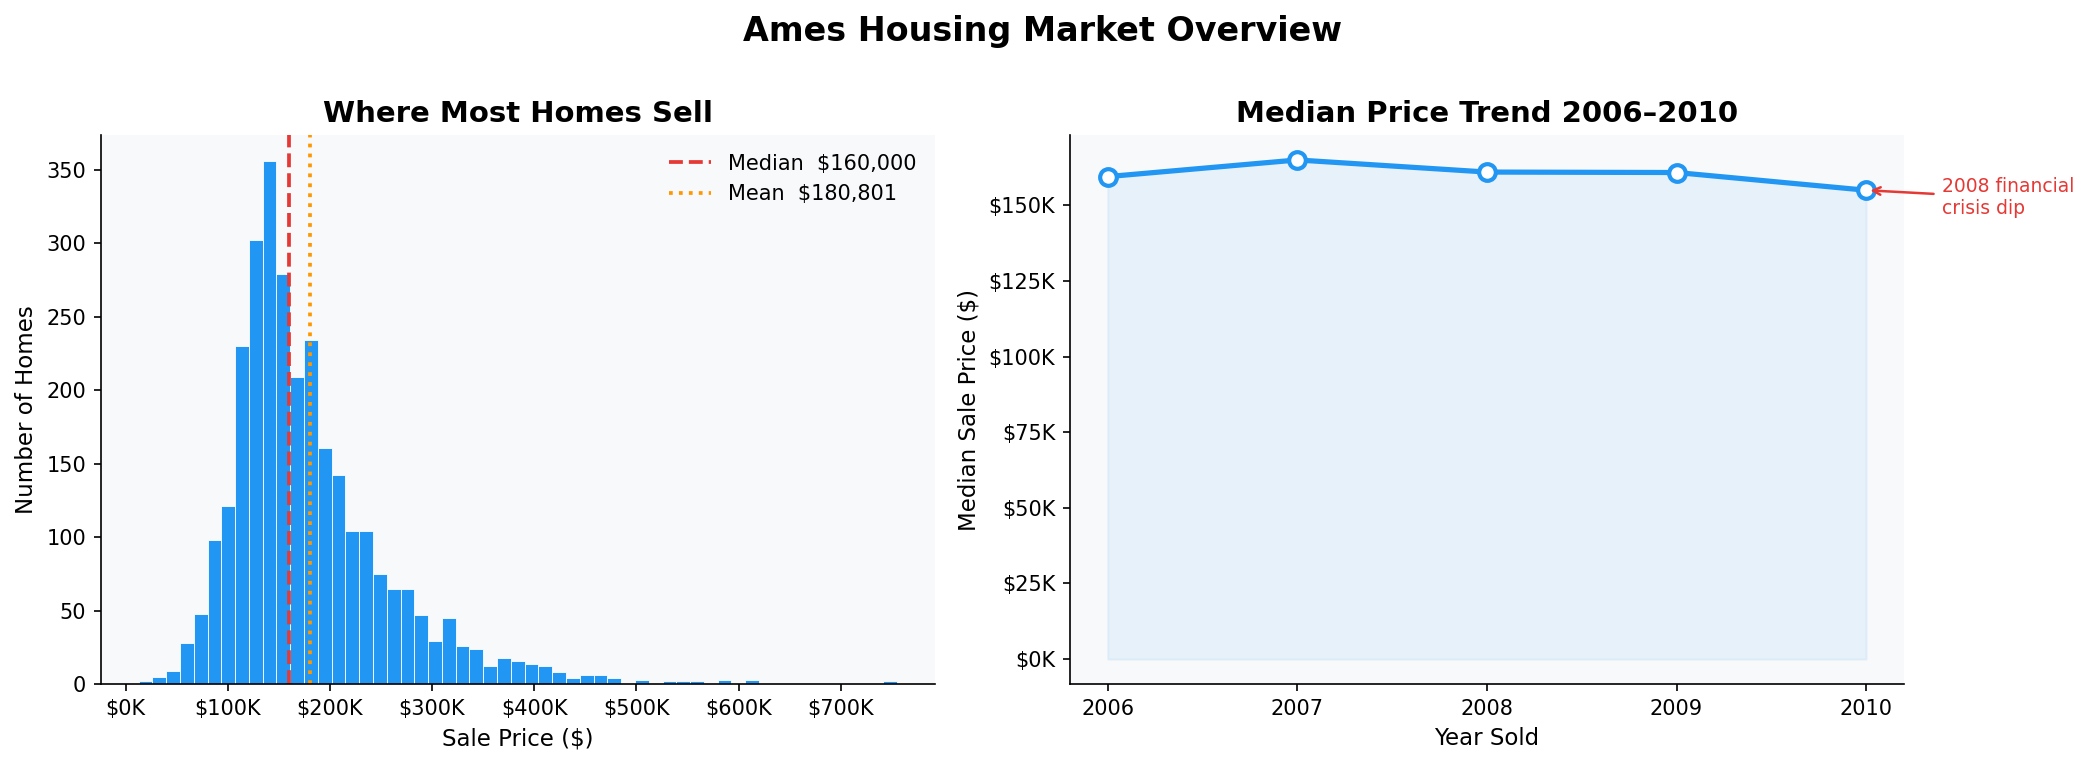

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution:

axes[0].hist(df['SalePrice'], bins=55,
             color='#2196F3', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['SalePrice'].median(), color='#E53935',
                linestyle='--', linewidth=1.8,
                label=f"Median  ${df['SalePrice'].median():,.0f}")
axes[0].axvline(df['SalePrice'].mean(), color='#FF9800',
                linestyle=':', linewidth=1.8,
                label=f"Mean  ${df['SalePrice'].mean():,.0f}")
axes[0].set_title('Where Most Homes Sell')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Number of Homes')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend(frameon=False)

# Price by year sold:

yr = df.groupby('Yr Sold')['SalePrice'].median()
axes[1].plot(yr.index.astype(str), yr.values,
             marker='o', color='#2196F3',
             linewidth=2.5, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(range(len(yr)), yr.values,
                     alpha=0.08, color='#2196F3')
axes[1].set_title('Median Price Trend 2006–2010')
axes[1].set_xlabel('Year Sold')
axes[1].set_ylabel('Median Sale Price ($)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Annotate the 2008 dip:

yr_list = yr.values.tolist()
dip_idx = yr_list.index(min(yr_list))
axes[1].annotate(
    '2008 financial\ncrisis dip',
    xy=(dip_idx, min(yr_list)),
    xytext=(dip_idx + 0.4, min(yr_list) - 8000),
    fontsize=9, color='#E53935',
    arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2)
)

plt.suptitle('Ames Housing Market Overview', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\07 Insight - Video\\Report\\insight_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Finding 2 — Quality Is the Single Biggest Value Driver

**What I found is:**  
Overall build quality — rated 1 to 10 — is the strongest predictor of price
across all neighborhoods and property sizes. A house rated 8 sells for roughly
twice the price of a house rated 5. No other single feature comes close.

**What it means for a client:**  
Pre-sale quality upgrades deliver the highest return on investment.
Buyers are paying a measurable premium for quality — not just size.
A property development strategy focused on finishing quality will
consistently outperform one focused purely on square footage.

#### Quality Chart

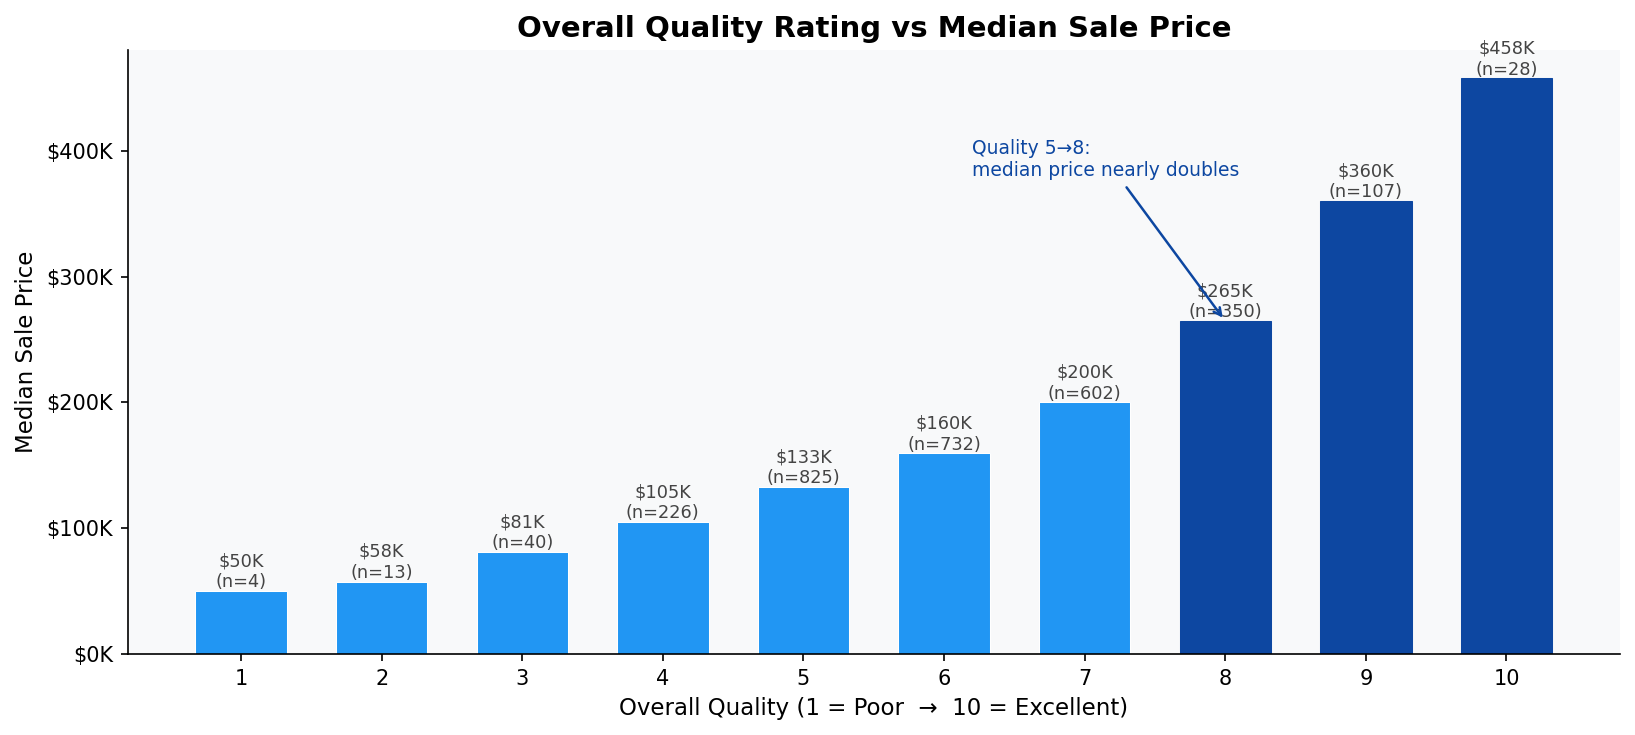

In [10]:
qual = (df.groupby('Overall Qual')['SalePrice']
          .agg(['median', 'count'])
          .reset_index()
          .rename(columns={'median': 'Median Price',
                           'count':  'Sales Count'}))

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(qual['Overall Qual'], qual['Median Price'],
              color='#2196F3', edgecolor='white',
              linewidth=0.5, width=0.65)

# Color top 3 quality bars differently:

for i, bar in enumerate(bars):
    if qual['Overall Qual'].iloc[i] >= 8:
        bar.set_color('#0D47A1')

# Label each bar with median price:

for bar, val, n in zip(bars,
                        qual['Median Price'],
                        qual['Sales Count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3000,
            f'${val/1000:.0f}K\n(n={n})',
            ha='center', fontsize=8.5, color='#444')

ax.set_title('Overall Quality Rating vs Median Sale Price',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Overall Quality (1 = Poor  →  10 = Excellent)')
ax.set_ylabel('Median Sale Price')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_xticks(range(1, 11))

# Add annotation arrow showing ROI jump from 5→8:

ax.annotate(
    'Quality 5→8:\nmedian price nearly doubles',
    xy=(8, qual[qual['Overall Qual']==8]['Median Price'].values[0]),
    xytext=(6.2, 380000),
    fontsize=9, color='#0D47A1',
    arrowprops=dict(arrowstyle='->', color='#0D47A1', lw=1.2)
)

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\07 Insight - Video\\Report\\insight_quality_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Finding 3 — Location Creates a 3× Price Spread Across Neighborhoods

**What I found is:**  
Neighborhood alone accounts for enormous price variation. The most expensive
neighborhoods (NridgHt, NoRidge, StoneBr) have median prices above $300,000.
The most affordable (MeadowV, IDOTRR, BrDale) sit below $100,000.
That is a 3× price spread within the same city.

**What it means for a client:**  
Neighborhood selection is the highest-leverage acquisition decision.
A mid-quality house in NridgHt will outperform a high-quality house
in MeadowV on absolute resale value. Location-first strategy is validated
by the data.

#### Neighborhood Chart

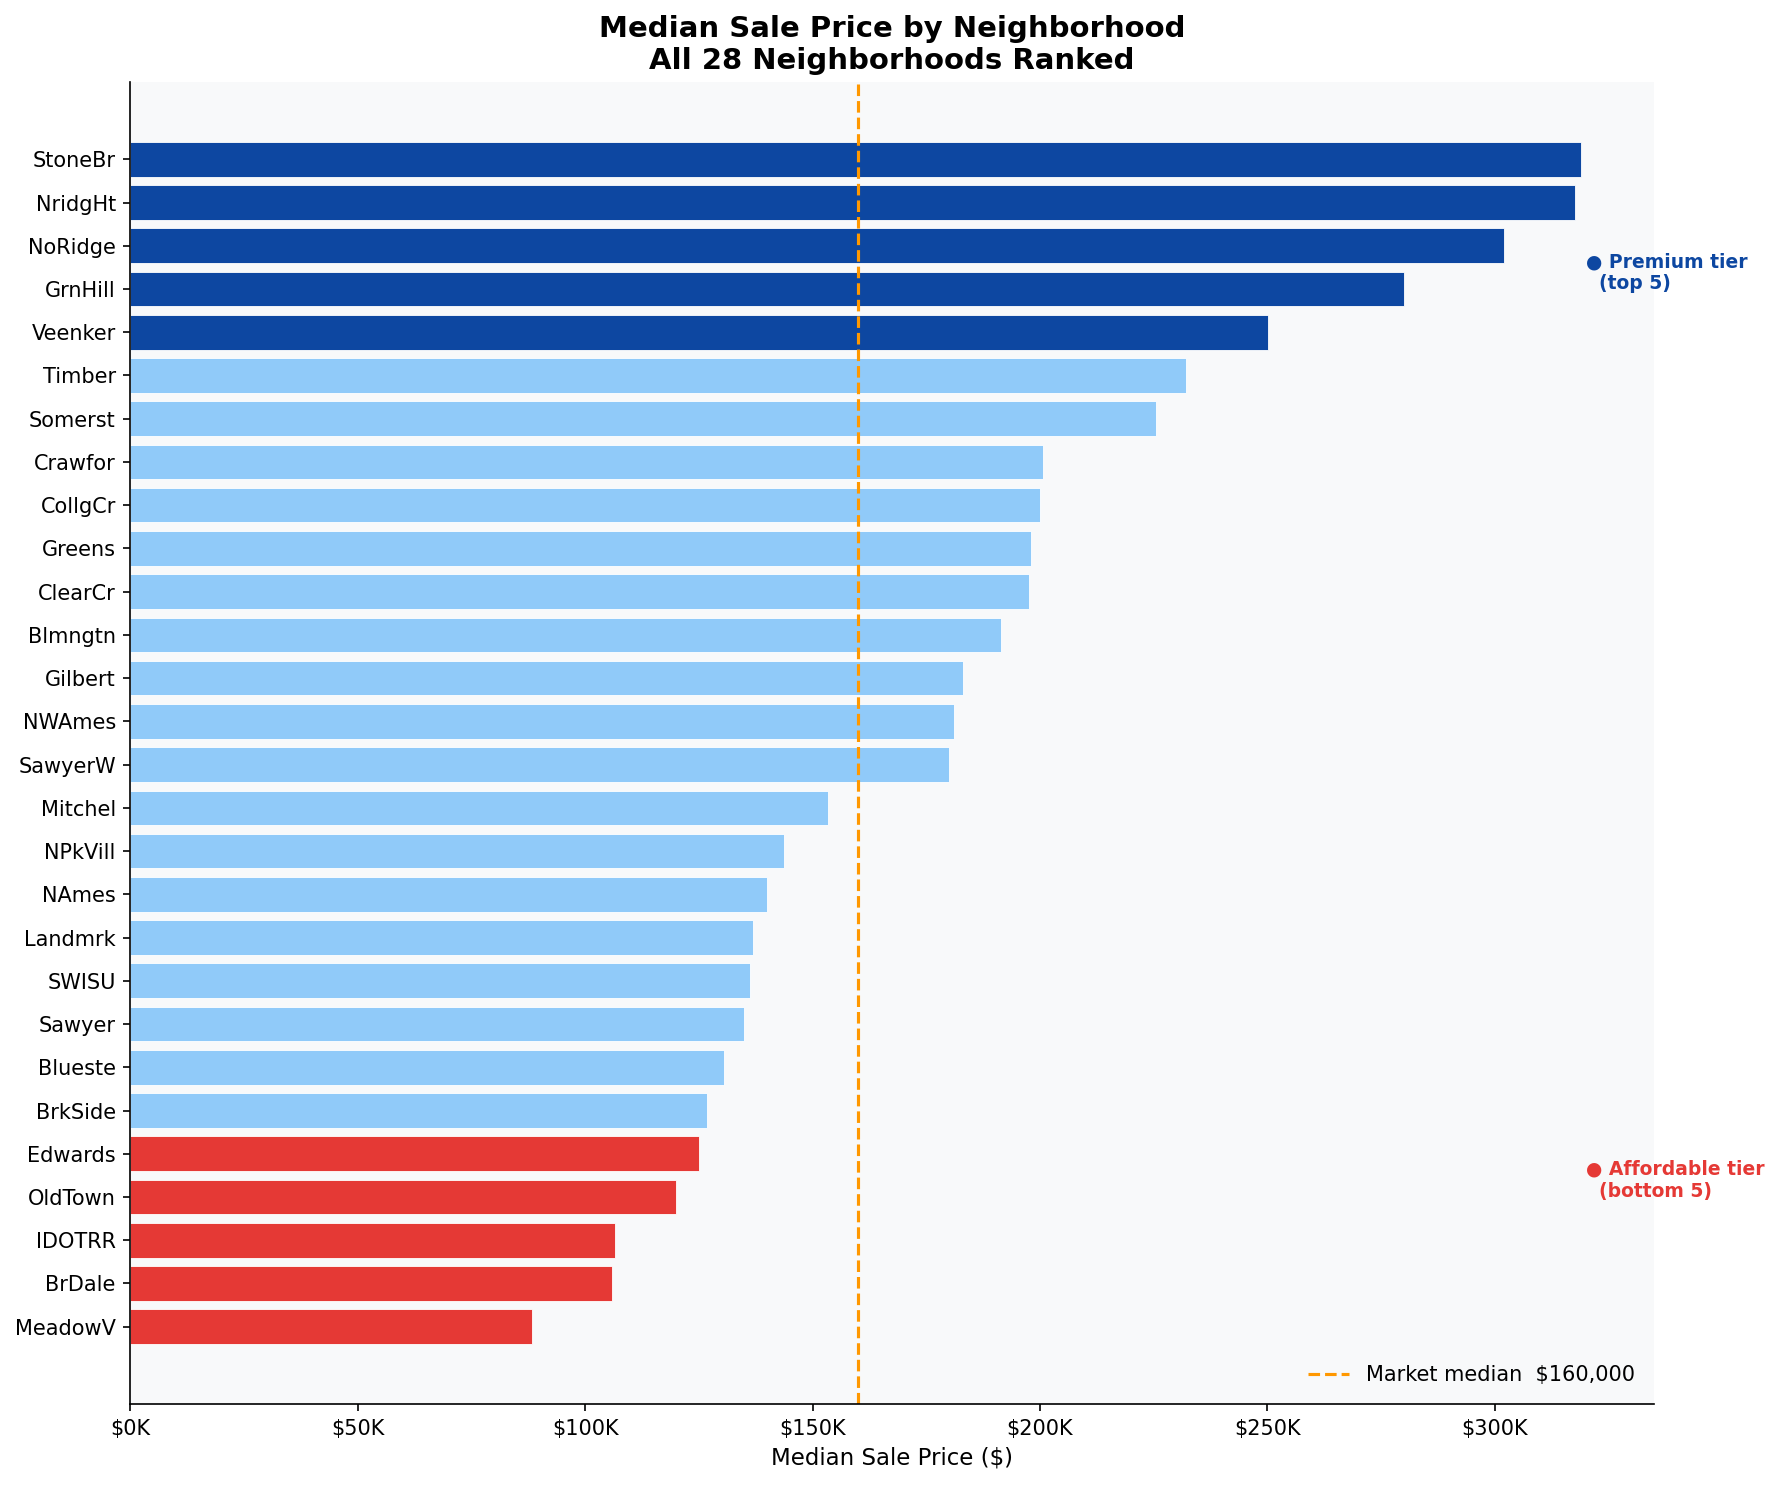

In [12]:
nbhd = (df.groupby('Neighborhood')['SalePrice']
          .median()
          .sort_values(ascending=True))

# Color code: top 5 premium, bottom 5 affordable, rest neutral:

colors = []
for i, nbhd_name in enumerate(nbhd.index):
    if i >= len(nbhd) - 5:
        colors.append('#0D47A1')   # premium — dark blue
    elif i < 5:
        colors.append('#E53935')   # affordable — red
    else:
        colors.append('#90CAF9')   # mid market — light blue

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(nbhd.index, nbhd.values,
               color=colors, edgecolor='white', linewidth=0.4)

ax.axvline(df['SalePrice'].median(), color='#FF9800',
           linestyle='--', linewidth=1.5,
           label=f"Market median  ${df['SalePrice'].median():,.0f}")
ax.set_title('Median Sale Price by Neighborhood\nAll 28 Neighborhoods Ranked',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Median Sale Price ($)')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(frameon=False, loc='lower right')

# Annotations:

ax.text(320000, 24,
        '● Premium tier\n  (top 5)',
        color='#0D47A1', fontsize=9, fontweight='bold')
ax.text(320000, 3,
        '● Affordable tier\n  (bottom 5)',
        color='#E53935', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\07 Insight - Video\\Report\\insight_neighborhood_ranking.png', dpi=150,
            bbox_inches='tight')
plt.show()

---
## Finding 4 — Size Matters, but Quality Multiplies It

**What I found is:**  
Above-ground living area is the #2 price driver. Every additional 500 sq ft
adds roughly $30,000–$50,000 in value on average. However, the relationship
is not uniform — a large house with low quality scores does not command
the same premium as a smaller house with high quality scores.

**What it means for a client:**  
Maximising square footage alone is not a winning strategy.
The data shows that size and quality interact — the highest sale prices
belong to houses that are *both* large *and* high quality.
For renovation projects: improving quality scores yields more reliable
returns than adding square footage.

#### Size Vs. Quality Chart

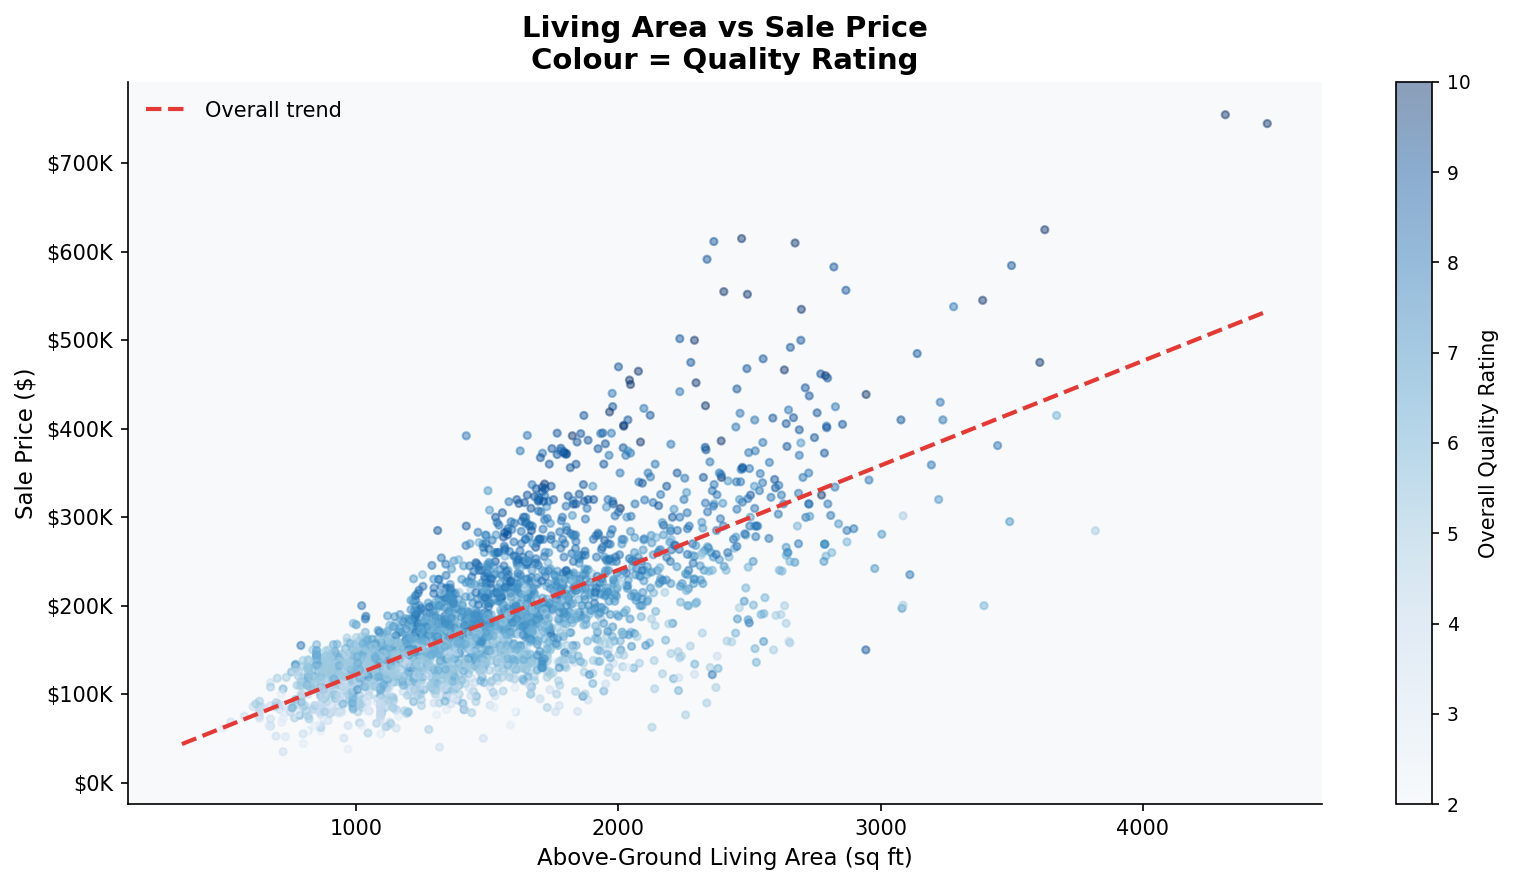

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

# Scatter colored by quality:

scatter = ax.scatter(
    df['Gr Liv Area'], df['SalePrice'],
    c=df['Overall Qual'],
    cmap='Blues', alpha=0.45, s=12,
    vmin=2, vmax=10
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Overall Quality Rating', fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Trend line:

m, b = np.polyfit(df['Gr Liv Area'], df['SalePrice'], 1)
x_line = np.array([df['Gr Liv Area'].min(),
                   df['Gr Liv Area'].max()])
ax.plot(x_line, m * x_line + b,
        color='#E53935', linewidth=2,
        linestyle='--', label='Overall trend')

ax.set_title('Living Area vs Sale Price\nColour = Quality Rating',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Above-Ground Living Area (sq ft)')
ax.set_ylabel('Sale Price ($)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\07 Insight - Video\\Report\\insight_size_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Finding 5 — Our Model Predicts Prices Within ±$18,342

**What I found is:**  
After testing four machine learning models, Ridge Regression delivered
the most reliable predictions — explaining 94.9% of all price variation
with an average error of $18,342.

| Model | Average Error | Reliability |
|---|---|---|
| Linear Regression | $19,100 | Good baseline |
| **Ridge Regression** | **$18,342** | **Best — recommended** |
| Lasso Regression | $18,594 | Good — lean model |
| Gradient Boosting | $20,721 | Overfit on this dataset |

**What it means for a client:**  
For a house listed at $200,000, our model's prediction will typically
fall within $182,000–$218,000. This is sufficient accuracy for:
- Pre-listing valuation checks
- Acquisition screening (is this priced fairly?)
- Portfolio valuation estimates
It is not a substitute for a formal RICS appraisal on individual high-value
transactions.

#### Model Performance Chart

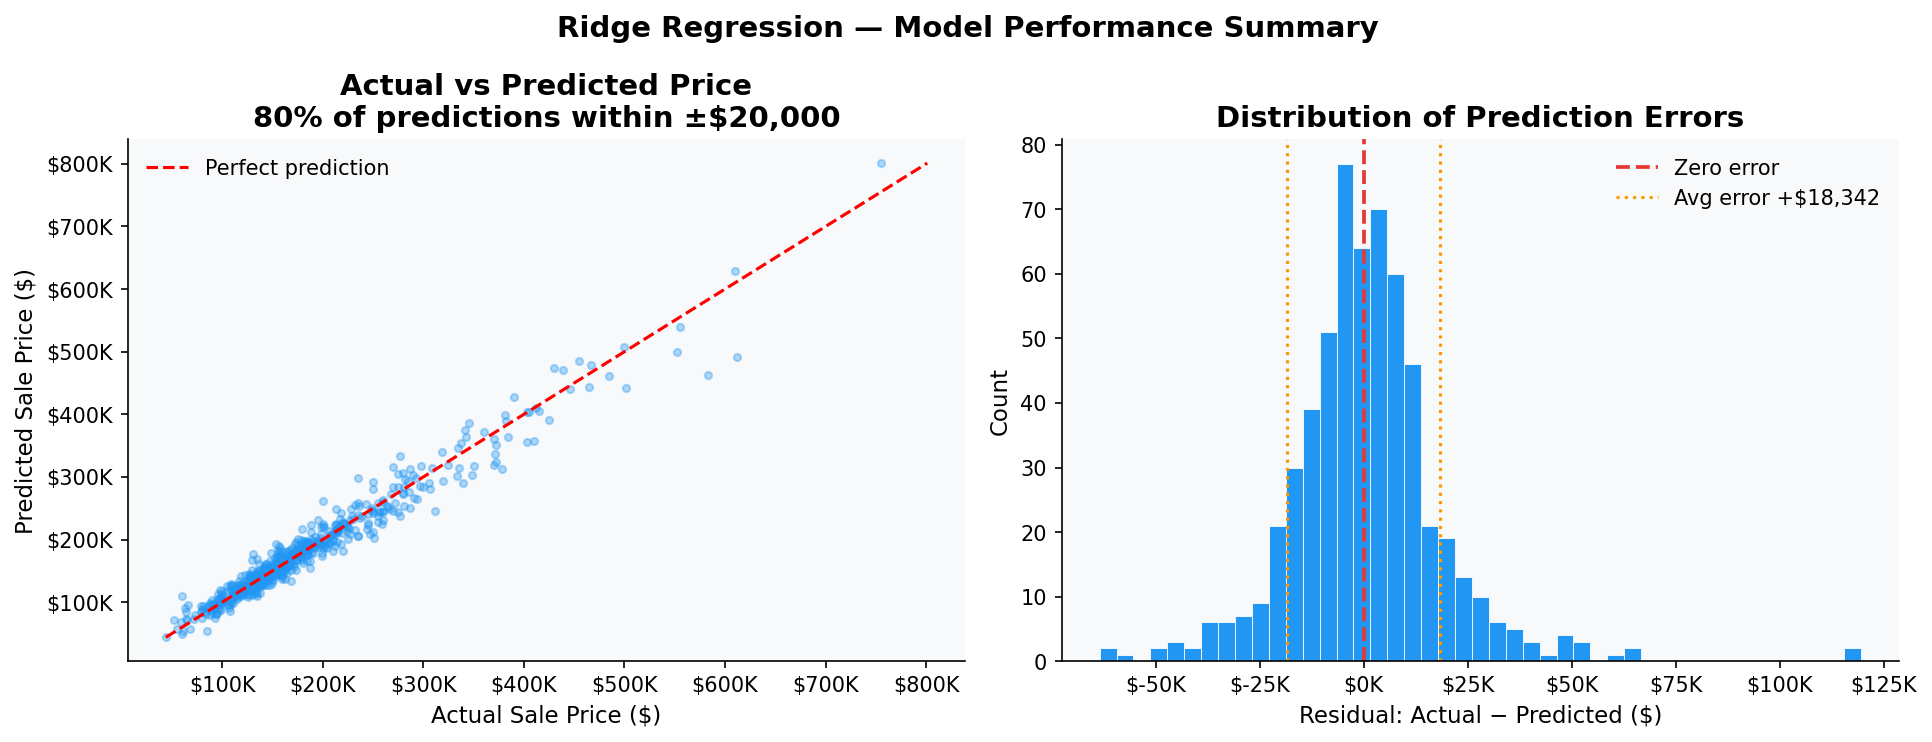


Predictions within ±$20,000: 80.4%


In [15]:
# Load predictions:

pred = pd.read_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\ridge_predictions.csv') \
       if __import__('os').path.exists(
           'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\ridge_predictions.csv') \
       else None

if pred is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Actual vs predicted:

    axes[0].scatter(pred['Actual_Price'], pred['Predicted_Price'],
                    alpha=0.35, color='#2196F3', s=12)
    lims = [min(pred['Actual_Price'].min(),
                pred['Predicted_Price'].min()),
            max(pred['Actual_Price'].max(),
                pred['Predicted_Price'].max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5,
                 label='Perfect prediction')
    axes[0].set_title('How Accurate Is the Model?')
    axes[0].set_xlabel('Actual Sale Price ($)')
    axes[0].set_ylabel('Predicted Sale Price ($)')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[0].legend(frameon=False)

    within_20k = (pred['Residual_Dollar'].abs() <= 20000).mean() * 100
    axes[0].set_title(
        f'Actual vs Predicted Price\n'
        f'{within_20k:.0f}% of predictions within ±$20,000'
    )

    # Error distribution:

    axes[1].hist(pred['Residual_Dollar'], bins=45,
                 color='#2196F3', edgecolor='white', linewidth=0.4)
    axes[1].axvline(0, color='#E53935', linestyle='--',
                    linewidth=1.8, label='Zero error')
    axes[1].axvline(18342, color='#FF9800', linestyle=':',
                    linewidth=1.5, label='Avg error +$18,342')
    axes[1].axvline(-18342, color='#FF9800', linestyle=':',
                    linewidth=1.5)
    axes[1].set_title('Distribution of Prediction Errors')
    axes[1].set_xlabel('Residual: Actual − Predicted ($)')
    axes[1].set_ylabel('Count')
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[1].legend(frameon=False)


    plt.suptitle('Ridge Regression — Model Performance Summary',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\07 Insight - Video\\Report\\insight_model_performance.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print(f"\nPredictions within ±$20,000: {within_20k:.1f}%")
else:
    print("ridge_predictions.csv not found — run Phase 5 first")

---
## Strategic Recommendations for Real Estate Clients

Based on the full analysis of 2,928 residential sales in Ames, Iowa,
I recommend the following actionable strategies:

### For property investors
1. **Target NridgHt, NoRidge, and StoneBr** for premium acquisitions —
   these neighborhoods consistently command median prices above $300K
   with strong sales volume
2. **Avoid acquiring low-quality stock in affordable-tier neighborhoods**
   — the compounding of low quality + weak location creates outsized
   downside risk
3. **Use the valuation model before any acquisition** — screen properties
   for over/underpricing relative to model predictions

### For developers and renovators
1. **Prioritise quality rating improvements above all else** —
   moving from a quality score of 5 to 8 historically doubles
   the median sale price
2. **Total square footage matters, but quality multiplies it** —
   build or renovate to high quality finish before adding size
3. **Time sales to avoid Q4** — the seasonality analysis shows
   spring and summer months (April–July) produce higher median
   sale prices than autumn and winter

### For estate agents
1. **Use the $18,342 RMSE as a pricing confidence interval** —
   any listing priced more than $18,000 above model prediction
   warrants a conversation about market positioning
2. **Lead with neighborhood comps, then quality** — these two
   factors explain the majority of buyer willingness to pay

---
## Limitations and Next Steps

**What this model does not capture:**
- Individual property condition not reflected in rating scores
- Micro-location effects within neighborhoods (corner lots, views, noise)
- Post-2010 market dynamics — the dataset ends in 2010

**Recommended next steps:**
- Refresh with current MLS data for live market application
- Integrate a geo-spatial layer (latitude/longitude) for within-neighborhood pricing
- Build a property-specific input form on top of the model for agent use

#### Insights Summary

In [16]:
# Save a clean summary CSV for reference:

summary = pd.DataFrame({
    'Finding': [
        'Market concentration',
        'Top quality premium',
        'Neighborhood spread',
        'Size-quality interaction',
        'Model accuracy'
    ],
    'Key number': [
        '$100K–$250K band = majority of sales',
        'Quality 8 = ~2× price of Quality 5',
        '3× spread: $80K (MeadowV) to $315K (NridgHt)',
        'Size + Quality 9–10 = highest prices',
        'Ridge RMSE = $18,342 · R² = 0.9486'
    ],
    'Business implication': [
        'Highest liquidity in mid-market',
        'Quality upgrades yield best ROI',
        'Location is the primary value lever',
        'Finish quality multiplies size premium',
        'Reliable pre-listing valuation tool'
    ]
})

summary.to_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\07 Insight - Video\\insights_summary.csv', index=False)
print("Insights summary saved ✓")
print(summary.to_string(index=False))

Insights summary saved ✓
                 Finding                                   Key number                   Business implication
    Market concentration         $100K–$250K band = majority of sales        Highest liquidity in mid-market
     Top quality premium           Quality 8 = ~2× price of Quality 5        Quality upgrades yield best ROI
     Neighborhood spread 3× spread: $80K (MeadowV) to $315K (NridgHt)    Location is the primary value lever
Size-quality interaction         Size + Quality 9–10 = highest prices Finish quality multiplies size premium
          Model accuracy           Ridge RMSE = $18,342 · R² = 0.9486    Reliable pre-listing valuation tool
